In [1]:
import os
from dotenv import load_dotenv
from langchain_groq import ChatGroq


load_dotenv()

model = ChatGroq(
    groq_api_key=os.getenv("GROQ_API_KEY"),
    model="llama-3.1-8b-instant",
    temperature=0.0
)

### **Pydantic scheme**

In [ ]:
from pydantic import BaseModel, Field

class graph_schema(BaseModel):
    topic : str = Field(description="The topic of the graph")
    post : str = Field(description="The linkedin post content")
    curated_post : str = Field(description="The curated linked post content")

In [3]:
def createPost(state : graph_schema) -> graph_schema:

    # convert the pydantic object into dictinory
    state = state.model_dump()
    topic = state['topic']
    post = model.invoke(f"write a linkedIn post about {topic}").content
    state['post'] = post
    return state

In [4]:
def curatePost(state : graph_schema) -> graph_schema:
    state = state.model_dump()

    post = state['post']

    curatePost = model.invoke(f"curated the following linkedin post with genz tone : {post}").content
    state['curated_post'] = curatePost

    return state

In [5]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

graph.add_node("create_Post", createPost)
graph.add_node("curate_post", curatePost)

graph.add_edge(START, "create_Post")
graph.add_edge("create_Post", "curate_post")
graph.add_edge("curate_post", END)

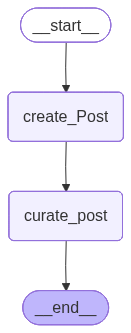

In [6]:
from IPython.display import Image, display

pydanticGraph = graph.compile()

#  display the graph
Image(pydanticGraph.get_graph().draw_mermaid_png())

In [ ]:
pydanticGraph.invoke({
    "topic" : "The importance of data privacy in the digital age",
    "post" : "",
    "curated_post" : ""
})